# 6.4 Regression Kriging with TensorFlow




**Dataset:** Great Plains soil survey (`data/gp_data_5000.csv`, `data/gp_grid.csv`)  

**Target:** Soil Organic Carbon (SOC, %)  

**Covariates:** NDVI, MAP, MAT, elevation, slope, TPI, aspect, K-factor, silt+clay, **NLCD (categorical)**

**Library:** `pygstat` v0.1.0 — `DeepRegressionKrigingTF`

***



## Table of Contents

1. [Overview](#1-overview)
2. [Mathematical Formulation](#2-mathematical-formulation)
3. [Python Setup](#3-python-setup)
   - 3.1 [CPU and GPU](#31-cpu-and-gpu)
4. [Load and Explore the Great Plains Data](#4-load-and-explore-the-great-plains-data)
5. [Prepare Features](#5-prepare-features)
6. [Stratified Train / Valid / Test Split](#6-stratified-train--valid--test-split)
7. [Exploratory Variogram of SOC](#7-exploratory-variogram-of-soc)
8. [Fit Deep Regression-Kriging Models](#8-fit-deep-regression-kriging-models)
9. [Hold-Out Comparison on the Test Set](#9-hold-out-comparison-on-the-test-set)
10. [Feature Importance](#10-feature-importance)
11. [Predict SOC on Grid Locations](#11-predict-soc-on-grid-locations)
12. [Map Predictions](#12-map-predictions)
13. [CPU vs GPU RK Timing](#13-cpu-vs-gpu-rk-timing)
14. [Summary and Conclusions](#14-summary-and-conclusions)
15. [Resources](#15-resources)


***
## 1. Overview

**Regression Kriging (RK)** combines a **deterministic trend** (here, a TensorFlow/Keras multilayer perceptron of SOC from environmental covariates) with **ordinary kriging of the residuals**. At location $\mathbf{s}$,

$$
Z(\mathbf{s}) = \hat{m}(\mathbf{s}) + \hat{e}(\mathbf{s})
$$

where $\hat{m}(\mathbf{s})$ is the neural-network prediction and $\hat{e}(\mathbf{s})$ is the kriged residual. Tutorial 7.1 uses scikit-learn-style trend models, tutorial 7.2 uses H2O-3, and tutorial 7.3 uses PyTorch; this notebook uses **TensorFlow/Keras** via `pygstat.DeepRegressionKrigingTF`.

The MLP is a feed-forward Keras `Sequential` network trained with Adam, dropout, and early stopping. TensorFlow uses a GPU automatically when one is registered (`tf.config.list_physical_devices('GPU')`). After the network is fit, training residuals are interpolated with a spherical ordinary-kriging model — the same residual step as in 7.1–7.3.

### This tutorial

We map **soil organic carbon** across the US Great Plains using **5,000** samples and a ~10 km prediction grid. **NLCD** land-cover class is **one-hot encoded** (a neural net has no native factor type). Samples are split **stratified by NLCD** into **train / valid / test**. Train is used to **fit and tune** the network (Optuna K-fold RMSE); valid is the **early-stopping** frame for the final refit; the **best of a default MLP vs the Optuna winner** is scored on the **test set** and then used to **predict SOC at grid locations**. Section 13 times residual **ordinary kriging** on **CPU vs GPU** for prefixes of `data/gp_data_5000.csv`.


### Deep trend models and Optuna search

| Setting | What it does |
|---------|--------------|
| `'default'` | Library defaults: hidden layers `[128, 64, 32]`, dropout $0.2$, learning rate $10^{-3}$, batch size $64$. A strong untuned baseline. |
| `'tuned'` | `tune_hyperparameters=True` runs an [Optuna](https://optuna.org) TPE search over architecture and optimizer settings, scores each trial by 3-fold CV RMSE (median pruning of weak trials), then **refits one MLP** on the full training set with the winning hyperparameters. |

This notebook’s `param_space` (a slightly tighter, tutorial-scale grid — the same shape as `pygstat.regression_kriging_tf._default_param_space`):

| Hyperparameter | Search |
|----------------|--------|
| Hidden layers | 1–3 layers, 32 / 64 / 128 / 256 units each |
| Dropout | $0$–$0.4$ |
| Learning rate | $10^{-4}$–$10^{-2}$ (log) |
| Weight decay | $10^{-6}$–$10^{-3}$ (log) |
| Batch size | 32 / 64 / 128 |

Pass a different `param_space(trial) -> dict` to widen the search. Residual kriging is still fit on **training** residuals only. Requires `pip install pygstat[optuna]` (or `pip install optuna`).


***
## 2. Mathematical Formulation

The target $Z(\mathbf{s})$ at location $\mathbf{s}$ is

$$
Z(\mathbf{s}) = \mu(\mathbf{s}) + \varepsilon(\mathbf{s})
$$

where $\mu(\mathbf{s})$ is a **deterministic trend** explained by covariates and $\varepsilon(\mathbf{s})$ is a **zero-mean, spatially autocorrelated residual**.

### Fit a Keras MLP trend

Covariates $\mathbf{x}(\mathbf{s})$ (NDVI, climate, terrain, soils, NLCD dummies) are standardized, then enter a feed-forward network $f_{\theta}$:

$$
\hat{\mu}(\mathbf{s}) = f_{\theta}\bigl(\mathbf{x}(\mathbf{s})\bigr)
$$

Each hidden layer is dense $\to$ ReLU $\to$ dropout. The network is trained by mini-batch Adam on mean squared error, with gradient clipping (`clipnorm=1.0`) and early stopping on the validation loss.

Hyperparameters $\theta$ (layer widths, dropout, learning rate, weight decay, batch size) are chosen by **Optuna**: trial $t$ is scored by K-fold validation RMSE, weak trials are pruned, and the minimizer is refit on the full training set.

### Residuals and variogram

$$
e_i = z_i - \hat{\mu}(\mathbf{s}_i), \quad i = 1, \ldots, n_{\mathrm{train}}
$$

$$
\hat{\gamma}(h) = \frac{1}{2|N(h)|} \sum_{(i,j) \in N(h)} (e_i - e_j)^2
$$

Spherical model:

$$
\gamma(h) =
\begin{cases}
c_0 + c \left(1.5 \frac{h}{a} - 0.5 \left(\frac{h}{a}\right)^3 \right), & h < a \\
c_0 + c, & h \geq a
\end{cases}
$$

### Ordinary kriging of residuals

$$
\hat{\varepsilon}(\mathbf{s}_0) = \sum_{i=1}^{n} \lambda_i e_i
$$

with the usual unbiasedness constraint $\sum_i \lambda_i = 1$. Final prediction:

$$
\hat{Z}(\mathbf{s}_0) = \hat{\mu}(\mathbf{s}_0) + \hat{\varepsilon}(\mathbf{s}_0)
$$

Kriging variance $\sigma_K^2(\mathbf{s}_0)$ is reported as a standard error when `return_std=True`.

### Why a neural net for the trend?

| Method | Pros | Cons |
|--------|------|------|
| sklearn ensembles (tutorial 7.1) | Simple Python API, native importances | No GPU training / AutoML-style architecture search |
| H2O GLM / DRF / GBM / AutoML (tutorial 7.2) | Native categoricals, grid search | Requires Java / H2O cluster |
| PyTorch MLP (tutorial 7.3) | Nonlinear capacity, GPU, Optuna architecture search | Needs dummy-coded factors; less interpretable |
| TensorFlow/Keras MLP (this notebook) | Same RK + Optuna API as 7.3; Keras ecosystem | Needs dummy-coded factors; TF/PyTorch GPU stacks should not share one process |

### Real-world example: soil organic carbon

- **Covariates:** NDVI, MAP, MAT, elevation, slope, TPI, aspect, K-factor, silt+clay, NLCD class
- **Trend:** SOC tends to increase with NDVI and MAP; land cover is a class effect, not a numeric score
- **Residuals:** unmeasured soil type, management, and local climate
- **RK:** the MLP captures the **global / nonlinear trend**; kriging adds **local spatial structure**


***
## 3. Python Setup

### 3.1 CPU and GPU

`DeepRegressionKrigingTF` has two independent backends:

| Argument / stack | What it controls |
|------------------|------------------|
| TensorFlow / Keras | MLP training and inference (GPU if `tf.config.list_physical_devices('GPU')` is non-empty). |
| `use_gpu` | Residual **ordinary kriging** covariance + solve (NumPy or CuPy). |

`use_gpu` is:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | GPU when CuPy can run a kernel on this card. Falls back to CPU otherwise. |
| `True` | Force GPU. Warns and falls back to CPU if CuPy is missing or cannot run a kernel. |
| `False` | Always CPU (NumPy/SciPy). |

This notebook probes the GPU once with `cupy_gpu_usable()` (a real op, not just `import cupy`) and stores the result in `USE_GPU`. Every `DeepRegressionKrigingTF(...)` call below passes `use_gpu=USE_GPU`. The Keras MLP still uses whatever TensorFlow devices are visible (which can be CPU-only even when CuPy works).

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.

Section 13 times residual OK (the kriging step inside `DeepRegressionKrigingTF`) on both backends using prefixes of `data/gp_data_5000.csv`.


In [1]:
%matplotlib inline

import sys
import warnings
from collections import Counter
from pathlib import Path

# pygstat optionally imports PyTorch for DeepRegressionKriging / GNN backends.
# Loading that stack in the same process as TensorFlow can crash; keep torch out.
sys.modules.setdefault("torch", None)

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

from IPython.display import display

import os
sys.path.insert(0, os.path.abspath("../src"))

import pygstat
from pygstat import DeepRegressionKrigingTF, Variogram
from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda v: f"{v:0.3f}")

print("tensorflow version:", tf.__version__)
print("built with CUDA   :", tf.test.is_built_with_cuda())
gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow GPUs   :", gpus if gpus else "none (CPU)")
if gpus:
    for gpu in gpus:
        details = tf.config.experimental.get_device_details(gpu)
        print("GPU               :", details.get("device_name", gpu))
else:
    print("Using device      : CPU")

try:
    import optuna
    print("optuna version    :", optuna.__version__)
except ImportError:
    raise ImportError(
        "This notebook needs Optuna for hyperparameter tuning. "
        "Install it with: pip install optuna  (or: pip install pygstat[optuna])"
    )

# ── Residual OK: CPU / GPU dispatch (CuPy; independent of TensorFlow GPU) ─────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`). Older cards can
# import CuPy and still fail at compile time; those stay on CPU.
print(f"pygstat version : {pygstat.__version__}")
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU (CuPy)      : {name}")
    except Exception:
        print("GPU (CuPy)      : available")
    print("Backend         : GPU (CuPy) — residual OK covariance + solve on GPU")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")


I0000 00:00:1788926388.692160  554174 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow version: 2.21.0
built with CUDA   : True
TensorFlow GPUs   : none (CPU)
Using device      : CPU
optuna version    : 5.0.0


E0000 00:00:1788926393.125635  554174 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1788926393.125665  554174 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
I0000 00:00:1788926393.125675  554174 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
I0000 00:00:1788926393.125690  554174 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1788926393.125693  554174 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: zia207-ThinkPad-P50
I0000 00:00:1788926393.125698  554174 cuda_diagnostics.cc:183] hostname: zia207-ThinkPad-P50
I0000 00:00:1788926393.125773  554174 cuda_diagnostics.cc:190] libcuda reported version is: 580.173.2
I0000 00:00:1788926393.125797  554174 cuda_diagnosti

pygstat version : 0.1.0
CuPy            : 14.2.0
GPU (CuPy)      : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — residual OK covariance + solve on GPU
use_gpu         : True


***
## 4. Load and Explore the Great Plains Data

Point samples live in `data/gp_data_5000.csv` (SOC plus covariates at 5,000 locations). The prediction grid is `data/gp_grid.csv` (covariates only). Coordinates are US Albers Equal Area (EPSG:5070), in metres.

The CSV header repeats `NLCD`; pandas renames the second copy to `NLCD.1`. That extra column is dropped. The first `NLCD` column matches the grid (classes 3–7).


In [2]:
DATA_DIR = Path("..") / "data"
df = pd.read_csv(DATA_DIR / "gp_data_5000.csv")
grid_df = pd.read_csv(DATA_DIR / "gp_grid.csv")
df = df.drop(columns=["NLCD.1"], errors="ignore")

print(f"Samples: {len(df):,}  |  Grid nodes: {len(grid_df):,}")
print("Sample columns:", list(df.columns))
print("Grid columns  :", list(grid_df.columns))
df.head()


Samples: 5,000  |  Grid nodes: 10,674
Sample columns: ['x', 'y', 'Aspect', 'ELEV', 'FRG', 'K_Factor', 'MAP', 'MAT', 'NDVI', 'NLCD', 'Silt_Clay', 'Slope', 'TPI', 'SOC']
Grid columns  : ['x', 'y', 'Aspect', 'ELEV', 'FRG', 'K_Factor', 'MAP', 'MAT', 'NDVI', 'NLCD', 'Silt_Clay', 'Slope', 'TPI']


,x,y,Aspect,ELEV,FRG,K_Factor,MAP,MAT,NDVI,NLCD,Silt_Clay,Slope,TPI,SOC
0,-955285,1723795,190.940,3253.481,3,0.215,509.138,1.762,0.556,4,43.669,16.048,-10.496,7.543
1,-735285,1973795,151.478,1464.636,2,0.213,346.082,9.494,0.598,7,48.345,1.105,-0.606,6.102
2,-975285,1103795,129.981,1441.645,133,0.113,372.746,15.772,0.240,5,38.460,12.090,2.134,3.612
3,-395285,1883795,143.176,841.139,2,0.320,548.891,10.720,0.483,6,87.090,2.587,-0.656,7.510
4,-925285,1173795,224.582,1490.576,3,0.284,357.764,14.428,0.216,5,53.868,6.122,0.595,2.378


In [3]:
print(df[["SOC", "NDVI", "MAP", "MAT", "ELEV", "Silt_Clay"]].describe().round(2))

NLCD_DES = {
    3: "Barren / other",
    4: "Forest",
    5: "Shrubland",
    6: "Herbaceous",
    7: "Planted/Cultivated",
}
print("\nNLCD classes (samples):")
print(
    df.groupby("NLCD").size().rename("n").to_frame()
    .assign(description=lambda s: s.index.map(NLCD_DES))
)


           SOC     NDVI      MAP      MAT     ELEV  Silt_Clay
count 5000.000 5000.000 5000.000 5000.000 5000.000   5000.000
mean     6.030    0.410  488.670    9.100 1657.040     53.890
std      3.700    0.160  213.480    4.180  743.290     16.410
min      0.030    0.050  153.580   -2.520  234.550      1.750
25%      3.240    0.270  345.480    6.290 1207.240     42.360
50%      5.120    0.380  424.780    9.570 1656.710     52.610
75%      8.030    0.530  585.630   12.420 2175.490     62.700
max     23.750    0.820 1749.110   17.880 3688.660     90.740

NLCD classes (samples):
         n         description
NLCD                          
3       19      Barren / other
4      956              Forest
5     1657           Shrubland
6     1519          Herbaceous
7      849  Planted/Cultivated


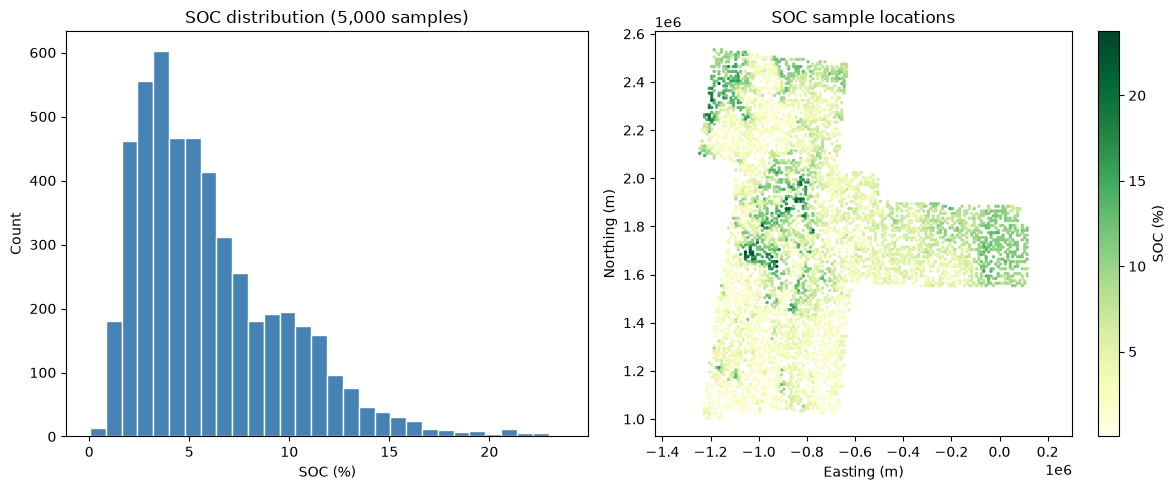

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df["SOC"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_xlabel("SOC (%)")
axes[0].set_ylabel("Count")
axes[0].set_title("SOC distribution (5,000 samples)")

sc = axes[1].scatter(df["x"], df["y"], c=df["SOC"], s=6, cmap="YlGn", edgecolors="none")
axes[1].set_xlabel("Easting (m)")
axes[1].set_ylabel("Northing (m)")
axes[1].set_title("SOC sample locations")
axes[1].set_aspect("equal", adjustable="datalim")
fig.colorbar(sc, ax=axes[1], label="SOC (%)")
plt.tight_layout()
plt.show()


***
## 5. Prepare Features

Unlike tutorial 7.2, **NLCD is not a native H2O factor**. A Keras MLP sees a numeric matrix, so land cover is **one-hot encoded** — the same encoding as tutorials 7.1 and 7.3:

- `OneHotEncoder(drop="first")` creates dummy columns and drops the first class as the baseline.
- The encoder is fit on the sample table and applied to the prediction grid (`handle_unknown="ignore"`).


In [5]:
required_cols = [
    "x", "y", "NDVI", "MAP", "MAT", "ELEV", "Slope", "TPI",
    "Aspect", "K_Factor", "Silt_Clay", "NLCD",
]
for col in required_cols:
    if col not in df.columns or col not in grid_df.columns:
        raise ValueError(f"Missing column: {col}")

numeric_cols = [
    "NDVI", "MAP", "MAT", "ELEV", "Slope", "TPI",
    "Aspect", "K_Factor", "Silt_Clay",
]
cat_cols = ["NLCD"]

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False,
    dtype=float,
)
encoder.fit(df[cat_cols])
nlcd_dummy_names = encoder.get_feature_names_out(cat_cols).tolist()
encoded_feature_names = numeric_cols + nlcd_dummy_names
baseline = encoder.categories_[0][0]


def encode_X(frame):
    num = frame[numeric_cols].to_numpy(dtype=float)
    cat = encoder.transform(frame[cat_cols])
    return np.hstack([num, cat])


X = encode_X(df)
y = df["SOC"].to_numpy(dtype=float)
coords = df[["x", "y"]].to_numpy(dtype=float)
X_grid = encode_X(grid_df)
coords_grid = grid_df[["x", "y"]].to_numpy(dtype=float)
nlcd_labels = df["NLCD"].to_numpy()

print("Numeric features:", numeric_cols)
print("NLCD categories :", list(encoder.categories_[0]))
print(f"Dropped baseline: {int(baseline)} ({NLCD_DES.get(int(baseline), '?')})")
print("Dummy columns   :", nlcd_dummy_names)
print("Encoded features:", encoded_feature_names)
print("X:", X.shape, "  y:", y.shape, "  coords:", coords.shape)
print("Grid X:", X_grid.shape)


Numeric features: ['NDVI', 'MAP', 'MAT', 'ELEV', 'Slope', 'TPI', 'Aspect', 'K_Factor', 'Silt_Clay']
NLCD categories : [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Dropped baseline: 3 (Barren / other)
Dummy columns   : ['NLCD_4', 'NLCD_5', 'NLCD_6', 'NLCD_7']
Encoded features: ['NDVI', 'MAP', 'MAT', 'ELEV', 'Slope', 'TPI', 'Aspect', 'K_Factor', 'Silt_Clay', 'NLCD_4', 'NLCD_5', 'NLCD_6', 'NLCD_7']
X: (5000, 13)   y: (5000,)   coords: (5000, 2)
Grid X: (10674, 13)


***
## 6. Stratified Train / Valid / Test Split

A **60% / 20% / 20%** split, stratified by NLCD so each land-cover class appears in train, valid, and test (`random_state=42`).

- **Train** — fit the MLP trend (and Optuna CV folds) and the residual variogram / kriging
- **Valid** — early-stopping frame for the **final** production MLP (`X_val`, `y_val` in `fit()`)
- **Test** — untouched hold-out used only after the best of default vs tuned is chosen


In [6]:
counts = Counter(nlcd_labels)
stratify_arg = nlcd_labels if min(counts.values()) >= 3 else None

(
    X_temp, X_test,
    y_temp, y_test,
    coords_temp, coords_test,
    nlcd_temp, nlcd_test,
) = train_test_split(
    X, y, coords, nlcd_labels,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=stratify_arg,
)

(
    X_train, X_valid,
    y_train, y_valid,
    coords_train, coords_valid,
    nlcd_train, nlcd_valid,
) = train_test_split(
    X_temp, y_temp, coords_temp, nlcd_temp,
    test_size=0.25,  # 0.25 * 0.80 = 0.20 overall
    random_state=42,
    shuffle=True,
    stratify=nlcd_temp if stratify_arg is not None else None,
)


def _nlcd_counts(arr):
    return sorted(Counter(arr).items())


print(f"Train: {len(X_train):,}  |  Valid: {len(X_valid):,}  |  Test: {len(X_test):,}")
print("NLCD train:", _nlcd_counts(nlcd_train))
print("NLCD valid:", _nlcd_counts(nlcd_valid))
print("NLCD test :", _nlcd_counts(nlcd_test))


Train: 3,000  |  Valid: 1,000  |  Test: 1,000
NLCD train: [(np.int64(3), 11), (np.int64(4), 574), (np.int64(5), 995), (np.int64(6), 911), (np.int64(7), 509)]
NLCD valid: [(np.int64(3), 4), (np.int64(4), 191), (np.int64(5), 331), (np.int64(6), 304), (np.int64(7), 170)]
NLCD test : [(np.int64(3), 4), (np.int64(4), 191), (np.int64(5), 331), (np.int64(6), 304), (np.int64(7), 170)]


***
## 7. Exploratory Variogram of SOC

Before residual kriging, look at the **raw SOC** variogram on the training coordinates. Lag count uses Scott's rule on pairwise distances, capped at 30 lags: bin width $h = 3.5 \, \mathrm{std}\,/\, n^{1/3}$.


In [7]:
# Scott's rule on a random subset keeps the n=3,000 distance matrix light
rng = np.random.default_rng(42)
idx = rng.choice(len(coords_train), size=min(1200, len(coords_train)), replace=False)
sample_xy = coords_train[idx]
distances = np.sqrt(((sample_xy[:, None, :] - sample_xy[None, :, :]) ** 2).sum(axis=2))
upper_triangle = distances[np.triu_indices_from(distances, k=1)]
std_dist = np.nanstd(upper_triangle)
n_pairs = len(upper_triangle)
scott_bin_width = 3.5 * std_dist / (n_pairs ** (1 / 3))
maxlag_soc = float(np.nanpercentile(upper_triangle, 50))
n_lags_soc = max(5, min(30, int(maxlag_soc / scott_bin_width)))
print(f"Using Scott rule → n_lags: {n_lags_soc}, maxlag: {maxlag_soc:.1f} m")


Using Scott rule → n_lags: 30, maxlag: 601664.4 m


In [8]:
vg = Variogram(
    coords_train, y_train,
    model="spherical",
    estimator="matheron",
    maxlag=maxlag_soc,
    n_lags=n_lags_soc,
    use_gpu="auto",
)
vg.fit()
mask = ~np.isnan(vg.experimental)
rmse_vg = np.sqrt(np.mean((vg.experimental[mask] - vg(vg.lags)[mask]) ** 2))
nugget, psill, rng_m = vg.fitted_params
print(f"Spherical model RMSE: {rmse_vg:.2f}")
print(f"nugget={nugget:.3f}, partial sill={psill:.3f}, range={rng_m:.1f} m")


Spherical model RMSE: 0.51
nugget=3.209, partial sill=10.594, range=300832.2 m


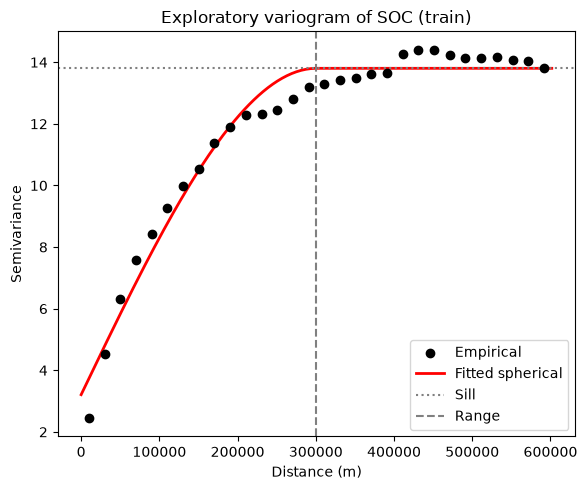

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(vg.lags, vg.experimental, color="black", label="Empirical", zorder=3)
h_fine = np.linspace(0, vg.maxlag, 200)
plt.plot(h_fine, vg(h_fine), color="red", linewidth=2, label="Fitted spherical")
plt.axhline(nugget + psill, color="gray", linestyle=":", label="Sill")
plt.axvline(rng_m, color="gray", linestyle="--", label="Range")
plt.xlabel("Distance (m)")
plt.ylabel("Semivariance")
plt.title("Exploratory variogram of SOC (train)")
plt.legend()
plt.tight_layout()
plt.show()


Residual variograms (next section) typically have a **shorter range** than the raw SOC variogram, because the regression has already absorbed the large-scale trend. Residual models use `maxlag=50` km and 15 lags — the same setting as tutorials 7.1–7.3.


***
## 8. Fit Deep Regression-Kriging Models

Two `DeepRegressionKrigingTF` trends are fit on the same train / valid split:

1. **`default`** — library architecture `[128, 64, 32]`, no search.
2. **`tuned`** — Optuna searches hidden-layer widths, dropout, learning rate, weight decay, and batch size (`n_trials=20`, 3-fold CV RMSE, median pruning). The winning trial is **refit** on the full training set with early stopping on the validation frame.

The **best of the two on the test set** is kept for mapping. Residual kriging uses training residuals only.


In [10]:
VARIOGRAM_KWARGS = {"maxlag": 50_000, "n_lags": 15}

COMMON = dict(
    use_gpu=USE_GPU,
    variogram_model="spherical",
    variogram_kwargs=VARIOGRAM_KWARGS,
    max_epochs=200,
    patience=20,
)


def param_space(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    hidden_layers = [
        trial.suggest_categorical(f"n_units_l{i}", [32, 64, 128, 256])
        for i in range(n_layers)
    ]
    return {
        "hidden_layers": hidden_layers,
        "dropout": trial.suggest_float("dropout", 0.0, 0.4),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
    }


FAMILY_SPECS = {
    "default": dict(
        hidden_layers=[128, 64, 32],
        dropout=0.2,
        learning_rate=1e-3,
        weight_decay=0.0,
        batch_size=64,
        tune_hyperparameters=False,
    ),
    "tuned": dict(
        tune_hyperparameters=True,
        param_space=param_space,
        n_trials=20,
        cv_folds=3,
        tuning_max_epochs=80,
        tuning_patience=10,
        tuning_seed=42,
        tuning_verbose=True,
    ),
}

fitted = {}
fit_errors = {}

for name, extra in FAMILY_SPECS.items():
    print(f"\n=== Fitting DeepRegressionKrigingTF '{name}' ===")
    try:
        rk = DeepRegressionKrigingTF(**COMMON, **extra)
        rk.fit(X_train, y_train, coords_train, X_val=X_valid, y_val=y_valid)
        fitted[name] = rk
        print("  ", rk)
        print("  fitted_params_:", rk.fitted_params_)
        if hasattr(rk, "best_score_"):
            print(f"  Optuna CV RMSE: {rk.best_score_:.4f}")
            trials = rk.study_.trials_dataframe()
            display(trials.sort_values("value").head(8))
    except Exception as exc:
        fit_errors[name] = str(exc)
        print(f"  FAILED: {exc}")

print("\nFitted families:", list(fitted))
if fit_errors:
    print("Failures:", fit_errors)



=== Fitting DeepRegressionKrigingTF 'default' ===
TensorFlow GPU devices: []


[I 2026-09-09 00:00:09,108] A new study created in memory with name: no-name-26e623ed-04ee-4c6d-8d73-fe4ba0f901f3


   DeepRegressionKrigingTF(hidden_layers=[128, 64, 32], variogram_model='spherical')
  fitted_params_: {'hidden_layers': [128, 64, 32], 'dropout': 0.2, 'learning_rate': 0.001, 'weight_decay': 0.0, 'batch_size': 64}

=== Fitting DeepRegressionKrigingTF 'tuned' ===
TensorFlow GPU devices: []


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-09 00:01:00,792] Trial 0 finished with value: 1.5778905588120091 and parameters: {'n_layers': 2, 'n_units_l0': 32, 'n_units_l1': 128, 'dropout': 0.2832290311184182, 'learning_rate': 0.00010994335574766199, 'weight_decay': 0.0008123245085588687, 'batch_size': 32}. Best is trial 0 with value: 1.5778905588120091.


...

[I 2026-09-09 00:09:57,414] Trial 18 finished with value: 1.2311873556710966 and parameters: {'n_layers': 3, 'n_units_l0': 256, 'n_units_l1': 64, 'n_units_l2': 128, 'dropout': 0.17729158987124194, 'learning_rate': 0.002438874252209161, 'weight_decay': 5.98748904202028e-05, 'batch_size': 64}. Best is trial 5 with value: 1.188941116433512.


[I 2026-09-09 00:10:08,050] Trial 19 pruned. 


   DeepRegressionKrigingTF(hidden_layers=[256, 64], variogram_model='spherical', tuned (best RMSE=1.189))
  fitted_params_: {'hidden_layers': [256, 64], 'dropout': 0.00220884684944096, 'learning_rate': 0.004274869455295219, 'weight_decay': 0.00013199942261535007, 'batch_size': 64}
  Optuna CV RMSE: 1.1889


,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_dropout,params_learning_rate,params_n_layers,params_n_units_l0,params_n_units_l1,params_n_units_l2,params_weight_decay,user_attrs_resolved_params,system_attrs_tpe:relative_params:0,state
5,5,1.189,2026-09-09 00:03:26.575614,2026-09-09 00:03:50.980329,0 days 00:00:24.404715,64,0.002,0.004,2,256,64.000,NaN,0.000,"{'hidden_layers': [256, 64], 'dropout': 0.0022...",NaN,COMPLETE
11,11,1.198,2026-09-09 00:06:33.859973,2026-09-09 00:07:10.677663,0 days 00:00:36.817690,64,0.114,0.001,3,256,64.000,256.000,0.001,"{'hidden_layers': [256, 64, 256], 'dropout': 0...","{""batch_size"": 64, ""dropout"": 0.11353200194085...",COMPLETE
13,13,1.200,2026-09-09 00:07:54.189585,2026-09-09 00:08:23.938010,0 days 00:00:29.748425,64,0.002,0.001,3,256,64.000,256.000,0.000,"{'hidden_layers': [256, 64, 256], 'dropout': 0...","{""batch_size"": 64, ""dropout"": 0.00181355366957...",COMPLETE
10,10,1.206,2026-09-09 00:05:53.321302,2026-09-09 00:06:33.857777,0 days 00:00:40.536475,64,0.125,0.001,3,256,64.000,256.000,0.001,"{'hidden_layers': [256, 64, 256], 'dropout': 0...","{""batch_size"": 64, ""dropout"": 0.12470804503987...",COMPLETE
9,9,1.228,2026-09-09 00:05:21.957280,2026-09-09 00:05:53.319271,0 days 00:00:31.361991,128,0.003,0.001,2,64,256.000,NaN,0.000,"{'hidden_layers': [64, 256], 'dropout': 0.0027...",NaN,COMPLETE
18,18,1.231,2026-09-09 00:09:30.033061,2026-09-09 00:09:57.414438,0 days 00:00:27.381377,64,0.177,0.002,3,256,64.000,128.000,0.000,"{'hidden_layers': [256, 64, 128], 'dropout': 0...","{""batch_size"": 64, ""dropout"": 0.17729158987124...",COMPLETE
12,12,1.233,2026-09-09 00:07:10.680318,2026-09-09 00:07:54.187411,0 days 00:00:43.507093,64,0.114,0.001,2,256,64.000,NaN,0.000,"{'hidden_layers': [256, 64], 'dropout': 0.1143...","{""batch_size"": 64, ""dropout"": 0.11434172337803...",COMPLETE
6,6,1.260,2026-09-09 00:03:50.983013,2026-09-09 00:04:15.369151,0 days 00:00:24.386138,128,0.255,0.006,2,64,256.000,NaN,0.000,"{'hidden_layers': [64, 256], 'dropout': 0.2550...",NaN,COMPLETE



Fitted families: ['default', 'tuned']


Training curves for each fitted MLP, and Optuna's optimization history for the tuned model.


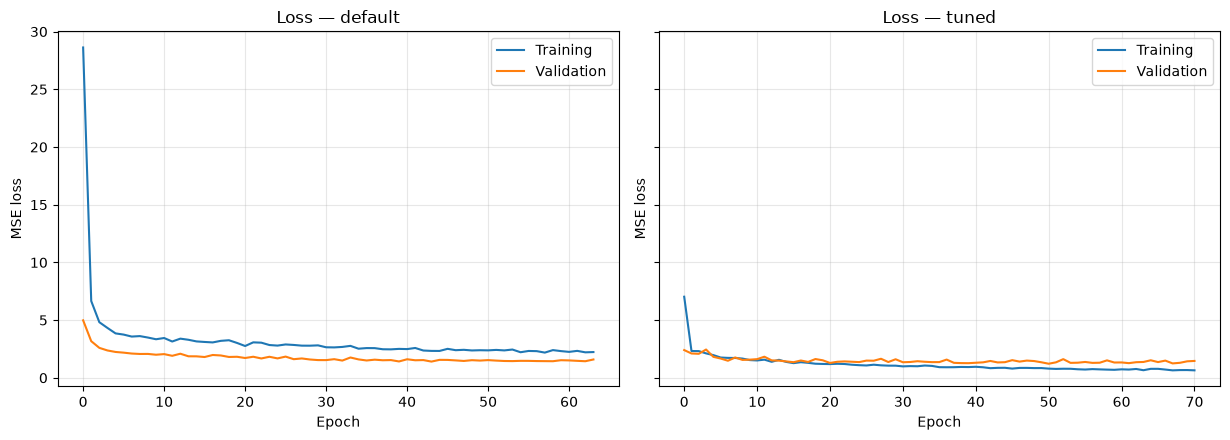

/home/zia207/Github/PyGStat/src/pygstat/regression_kriging_tf.py:438: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(self.study_)


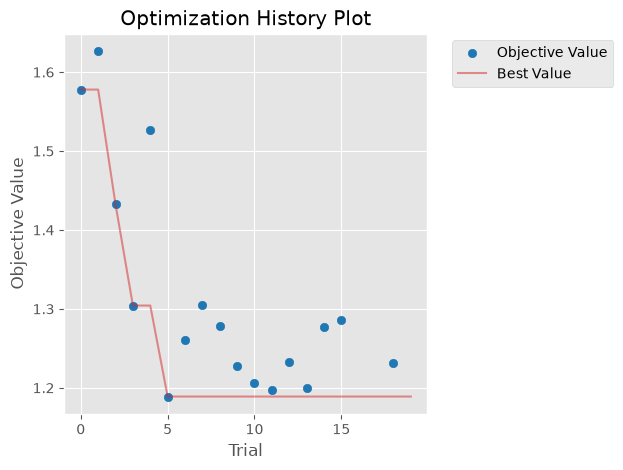

In [11]:
n = len(fitted)
fig, axes = plt.subplots(1, max(n, 1), figsize=(6.2 * max(n, 1), 4.5), sharey=True)
if n <= 1:
    axes = [axes]
for ax, (name, rk) in zip(np.atleast_1d(axes).ravel(), fitted.items()):
    ax.plot(rk.history_["loss"], label="Training")
    if "val_loss" in rk.history_:
        ax.plot(rk.history_["val_loss"], label="Validation")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss")
    ax.set_title(f"Loss — {name}")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

if "tuned" in fitted:
    fitted["tuned"].plot_optuna_history()


***
## 9. Hold-Out Comparison on the Test Set

The models above never saw the test coordinates. For each family we report RMSE, MAE, and $R^2$ of the **full RK prediction** (MLP trend + kriged residual) on the 20% test set.


In [12]:
rows = []
for name, rk in fitted.items():
    y_hat = rk.predict(X_test, coords_test)
    rows.append({
        "family": name,
        "hidden_layers": rk.fitted_params_["hidden_layers"],
        "dropout": rk.fitted_params_["dropout"],
        "learning_rate": rk.fitted_params_["learning_rate"],
        "batch_size": rk.fitted_params_["batch_size"],
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, y_hat))),
        "test_mae": float(mean_absolute_error(y_test, y_hat)),
        "test_r2": float(r2_score(y_test, y_hat)),
        "y_pred_test": y_hat,
    })

results = pd.DataFrame(rows).drop(columns=["y_pred_test"])
results = results.sort_values("test_rmse").reset_index(drop=True)
best_name = results.iloc[0]["family"]
print(f"Best family on the test set: {best_name}")
results


Best family on the test set: tuned


,family,hidden_layers,dropout,learning_rate,batch_size,test_rmse,test_mae,test_r2
0,tuned,"[256, 64]",0.002,0.004,64,1.021,0.697,0.927
1,default,"[128, 64, 32]",0.200,0.001,64,1.048,0.720,0.923


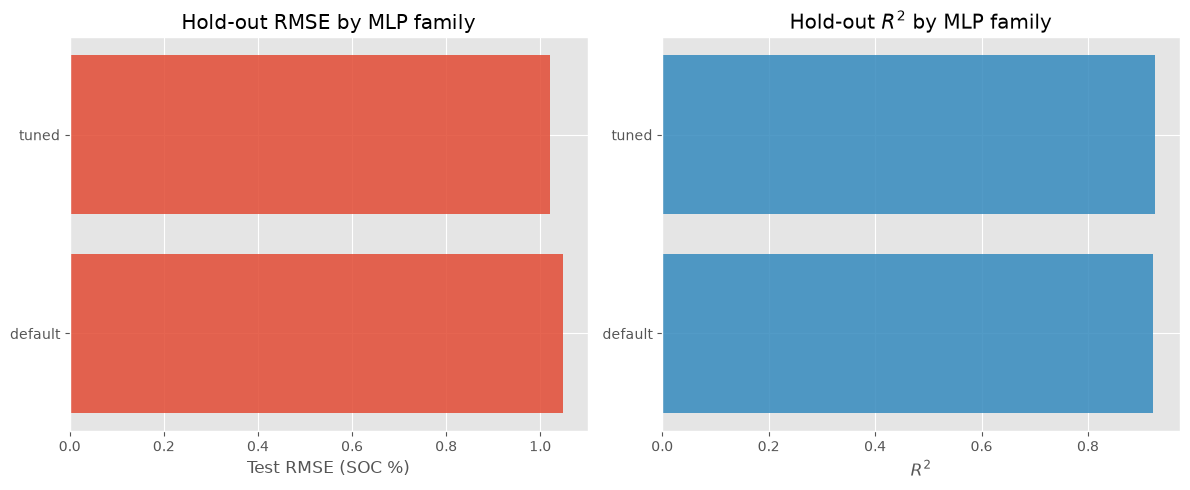

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = results.sort_values("test_rmse")
axes[0].barh(order["family"], order["test_rmse"], color="C0", alpha=0.85)
axes[0].set_xlabel("Test RMSE (SOC %)")
axes[0].set_title("Hold-out RMSE by MLP family")
axes[0].invert_yaxis()

axes[1].barh(order["family"], order["test_r2"], color="C1", alpha=0.85)
axes[1].set_xlabel("$R^2$")
axes[1].set_title("Hold-out $R^2$ by MLP family")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


### Observed vs predicted on the test set

One-to-one plots for the best family and the other fitted MLP.


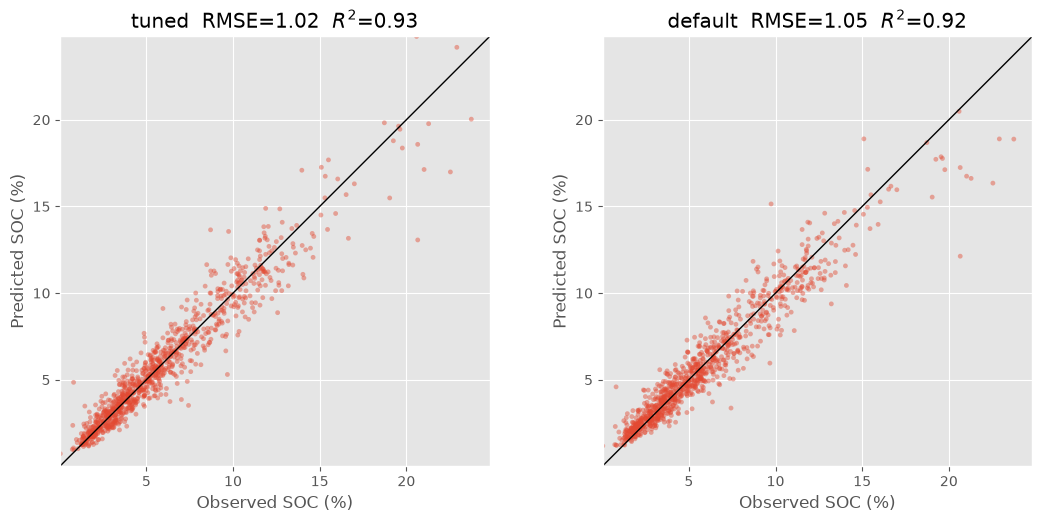

In [14]:
show = [best_name]
for extra in ("tuned", "default"):
    if extra in fitted and extra not in show:
        show.append(extra)

pred_lookup = {row["family"]: row for row in rows}
fig, axes = plt.subplots(1, len(show), figsize=(5.5 * len(show), 5.2))
if len(show) == 1:
    axes = [axes]
lims = [
    min(y_test.min(), min(pred_lookup[n]["y_pred_test"].min() for n in show)),
    max(y_test.max(), max(pred_lookup[n]["y_pred_test"].max() for n in show)),
]
for ax, name in zip(np.atleast_1d(axes).ravel(), show):
    y_hat = pred_lookup[name]["y_pred_test"]
    ax.scatter(y_test, y_hat, s=12, alpha=0.45, edgecolors="none")
    ax.plot(lims, lims, color="black", linewidth=1)
    ax.set_title(
        f"{name}  RMSE={pred_lookup[name]['test_rmse']:.2f}  "
        f"$R^2$={pred_lookup[name]['test_r2']:.2f}"
    )
    ax.set_xlabel("Observed SOC (%)")
    ax.set_ylabel("Predicted SOC (%)")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
plt.tight_layout()
plt.show()


### Residual variograms of two trend models

The residual variogram depends on the trend: a better-tuned MLP typically leaves **less structured** residual spatial variation (smaller sill / shorter range).


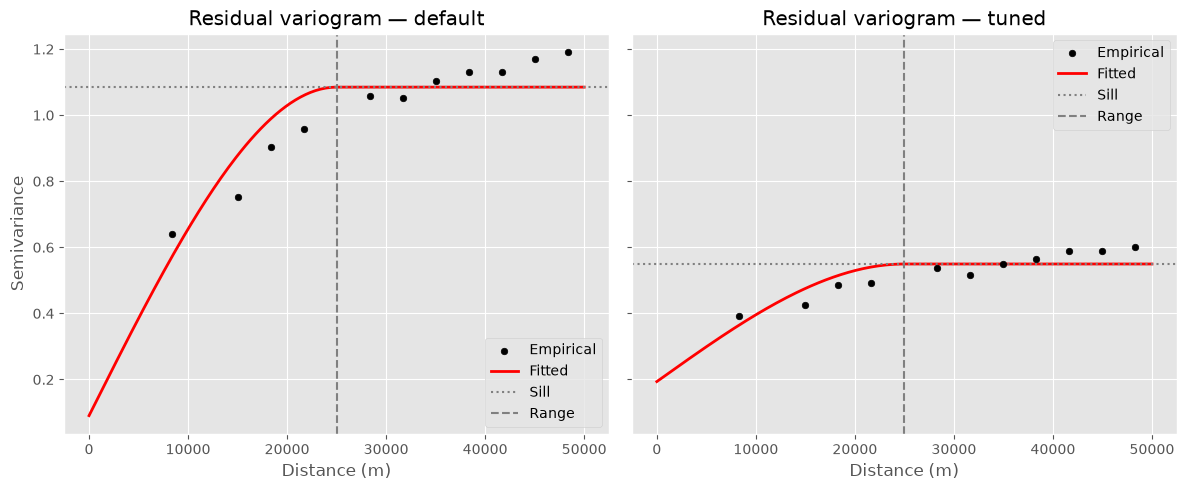

In [15]:
pair = [n for n in ("default", best_name) if n in fitted]
if len(pair) < 2:
    pair = list(fitted.keys())[:2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, name in zip(axes, pair):
    vg_r = fitted[name].variogram_
    h_fine = np.linspace(0, vg_r.maxlag, 200)
    ax.scatter(vg_r.lags, vg_r.experimental, color="black", s=22, label="Empirical", zorder=3)
    ax.plot(h_fine, vg_r(h_fine), color="red", linewidth=2, label="Fitted")
    nug, ps, rng_r = vg_r.fitted_params
    ax.axhline(nug + ps, color="gray", linestyle=":", label="Sill")
    ax.axvline(rng_r, color="gray", linestyle="--", label="Range")
    ax.set_xlabel("Distance (m)")
    ax.set_title(f"Residual variogram — {name}")
    ax.legend()
axes[0].set_ylabel("Semivariance")
plt.tight_layout()
plt.show()


***
## 10. Feature Importance

A feed-forward MLP has no native split-based importances. We report **permutation importance** on the test set: each encoded feature is shuffled in turn, and the increase in RK RMSE is the importance. Residuals depend only on coordinates, so permuting $X$ isolates the **trend** contribution.


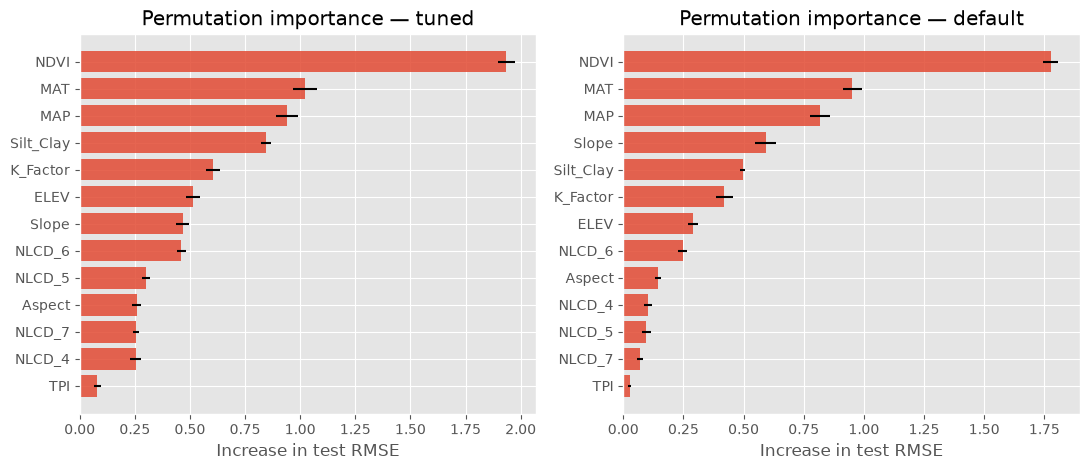

In [16]:
def permutation_importance_rk(rk, X, y, coords, feature_names, n_repeats=8, seed=42):
    baseline = np.sqrt(mean_squared_error(y, rk.predict(X, coords)))
    rng = np.random.default_rng(seed)
    rows = []
    for j, name in enumerate(feature_names):
        deltas = []
        for _ in range(n_repeats):
            Xp = np.array(X, copy=True)
            rng.shuffle(Xp[:, j])
            rmse = np.sqrt(mean_squared_error(y, rk.predict(Xp, coords)))
            deltas.append(rmse - baseline)
        rows.append({
            "feature": name,
            "importance": float(np.mean(deltas)),
            "std": float(np.std(deltas)),
        })
    return pd.DataFrame(rows).sort_values("importance")


imp_names = [n for n in (best_name, "tuned", "default") if n in fitted]
seen = []
for n in imp_names:
    if n not in seen:
        seen.append(n)
imp_names = seen[:2]

fig, axes = plt.subplots(1, max(1, len(imp_names)), figsize=(5.5 * max(1, len(imp_names)), 4.8))
if len(imp_names) <= 1:
    axes = [axes]
for ax, name in zip(np.atleast_1d(axes).ravel(), imp_names):
    imp = permutation_importance_rk(
        fitted[name], X_test, y_test, coords_test, encoded_feature_names
    )
    ax.barh(imp["feature"], imp["importance"], xerr=imp["std"], color="C0", alpha=0.85)
    ax.set_title(f"Permutation importance — {name}")
    ax.set_xlabel("Increase in test RMSE")
plt.tight_layout()
plt.show()


***
## 11. Predict SOC on Grid Locations

Each fitted family predicts at the `gp_grid.csv` nodes. For the best family we also store the **regression-only** surface, **kriged residuals**, and kriging standard error.


In [17]:
print("Predicting SOC on the grid for every MLP family ...")
for name, rk in fitted.items():
    grid_df[f"SOC_{name}"] = rk.predict(X_grid, coords_grid)

best_rk = fitted[best_name]
soc_best, se_best = best_rk.predict(X_grid, coords_grid, return_std=True)
grid_df["SOC_best"] = soc_best
grid_df["SOC_best_se"] = se_best

# Regression-only trend = RK prediction minus kriged residual
grid_df["resid_best"] = best_rk.krige_.predict(coords_grid)
grid_df["reg_best"] = grid_df["SOC_best"] - grid_df["resid_best"]

print(grid_df[["x", "y", "SOC_best", "SOC_best_se", "reg_best", "resid_best"]].describe())


Predicting SOC on the grid for every MLP family ...


                 x           y  SOC_best  SOC_best_se  reg_best  resid_best
count    10674.000   10674.000 10674.000    10674.000 10674.000   10674.000
mean   -753412.225 1757164.871     5.994        0.506     5.965       0.029
std     327749.190  382369.477     3.628        0.317     3.594       0.497
min   -1245285.000 1003795.000     0.389        0.000     0.833      -8.131
25%   -1005285.000 1503795.000     3.232        0.000     3.186      -0.147
50%    -825285.000 1743795.000     5.101        0.690     5.126       0.032
75%    -625285.000 2023795.000     7.927        0.711     7.955       0.208
max     114715.000 2533795.000    24.806        0.741    24.750       5.503


In [18]:
out_path = DATA_DIR / "gp_prediction_RK_tf.csv"
grid_df.to_csv(out_path, index=False)
print(f"Grid predictions saved to {out_path}")


Grid predictions saved to ../data/gp_prediction_RK_tf.csv


***
## 12. Map Predictions

Points are plotted in EPSG:5070 with Great Plains state boundaries (`data/GP_STATE.shp`).


In [19]:
states = gpd.read_file(DATA_DIR / "GP_STATE.shp")
gdf_pred = gpd.GeoDataFrame(
    grid_df,
    geometry=gpd.points_from_xy(grid_df.x, grid_df.y),
    crs="EPSG:5070",
)
states = states.to_crs(gdf_pred.crs)


def map_points(ax, column, cmap, title, vmin=None, vmax=None):
    gdf_pred.plot(
        column=column, ax=ax, legend=True, cmap=cmap,
        markersize=4, vmin=vmin, vmax=vmax,
        legend_kwds={"shrink": 0.7},
    )
    states.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(title)
    ax.set_axis_off()


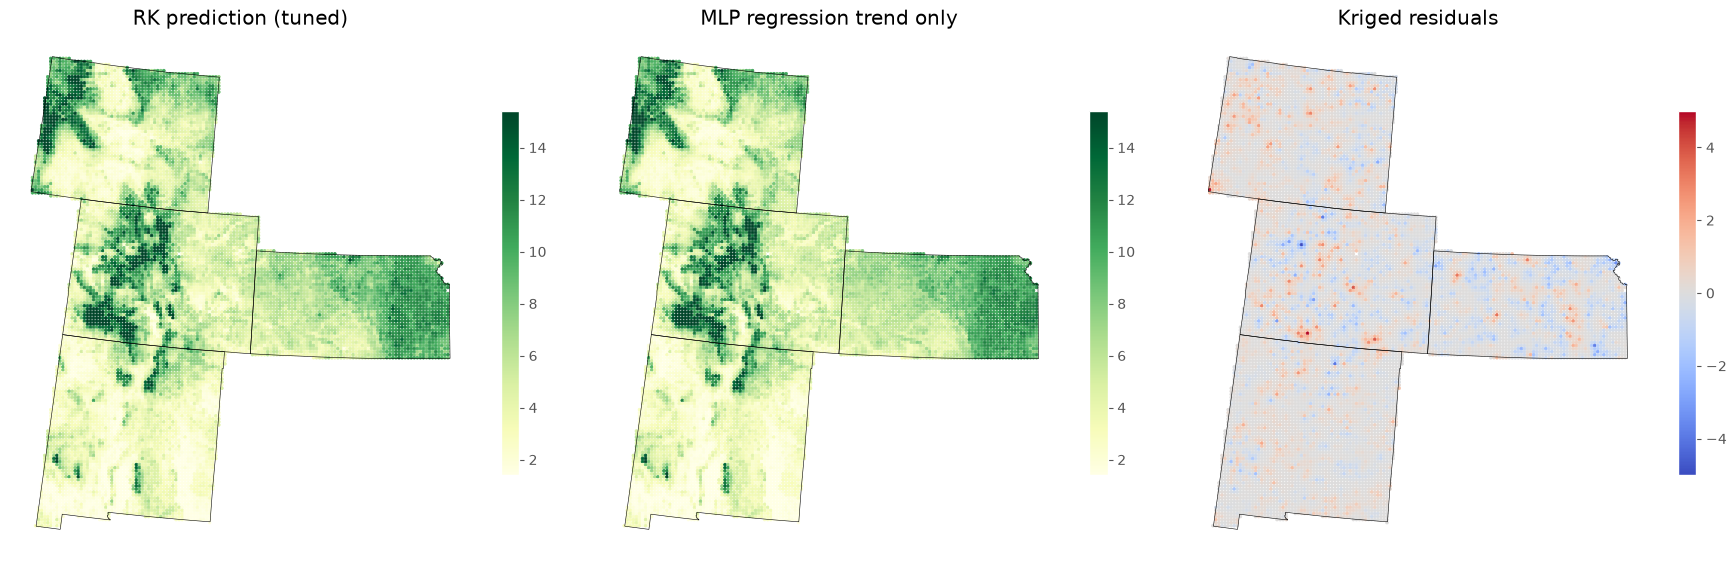

In [20]:
vmin = np.nanpercentile(grid_df["SOC_best"], 2)
vmax = np.nanpercentile(grid_df["SOC_best"], 98)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
map_points(axes[0], "SOC_best", "YlGn", f"RK prediction ({best_name})", vmin, vmax)
map_points(axes[1], "reg_best", "YlGn", "MLP regression trend only", vmin, vmax)
map_points(axes[2], "resid_best", "coolwarm", "Kriged residuals",
           vmin=-5, vmax=5)
plt.tight_layout()
plt.show()


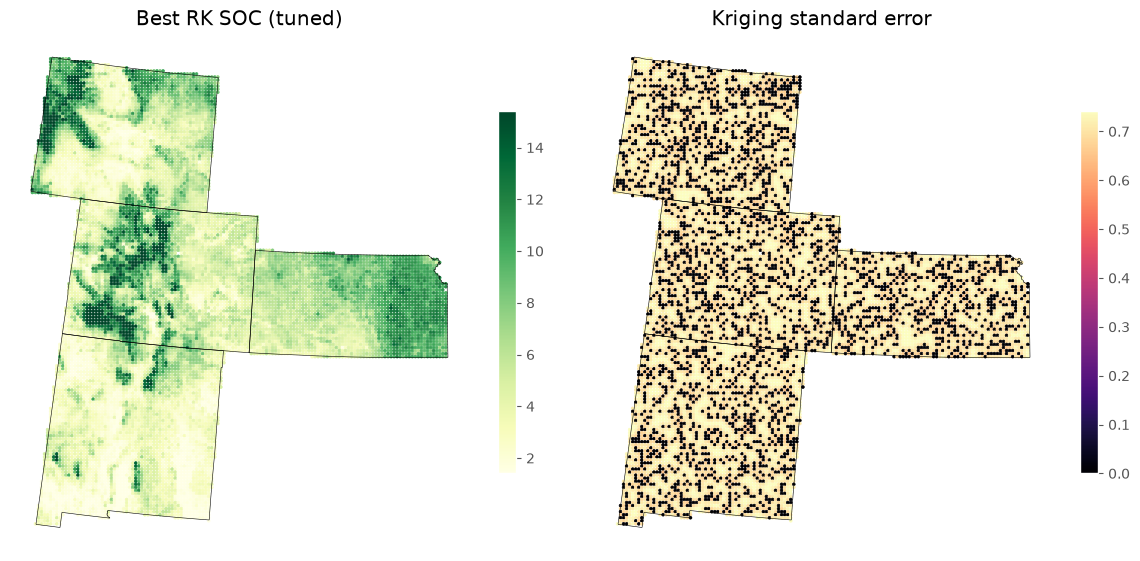

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
map_points(axes[0], "SOC_best", "YlGn", f"Best RK SOC ({best_name})", vmin, vmax)
map_points(axes[1], "SOC_best_se", "magma", "Kriging standard error")
plt.tight_layout()
plt.show()


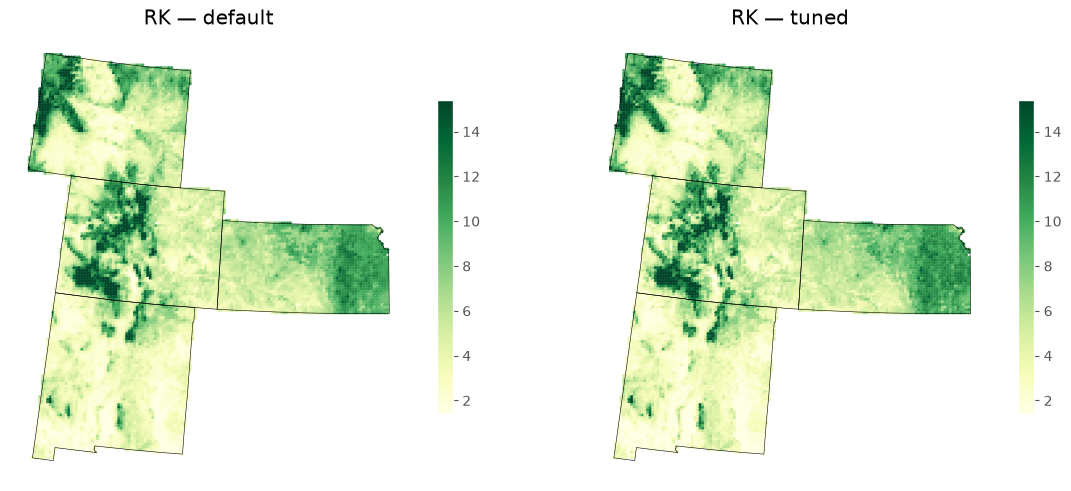

In [22]:
# Side-by-side grid predictions for every MLP family
model_names = list(fitted)
n = len(model_names)
ncols = min(2, n)
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, name in zip(axes, model_names):
    map_points(ax, f"SOC_{name}", "YlGn", f"RK — {name}", vmin, vmax)
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()


***
## 13. CPU vs GPU RK Timing

Section 3.1 showed how to *select* a backend. Here we measure how long **residual ordinary kriging** — the spatial step inside `DeepRegressionKrigingTF` — takes on **CPU** (`use_gpu=False`, NumPy/SciPy) versus **GPU** (`use_gpu=True`, CuPy) for prefixes of the Great Plains SOC survey (`data/gp_data_5000.csv`, $n$ up to 5{,}000).

The Keras MLP trend uses TensorFlow's own devices and is **not** part of these timings (training an MLP at every $n$ would dwarf the kriging solve). The GPU-accelerated steps are the $n \times n$ residual covariance among training points, the $n_{\text{pred}} \times n$ covariance to the targets, and the linear solve of the **augmented** OK system. A linear trend (an MLP analogue for residual extraction) is fit once per prefix; that fit and the residual variogram are **not** included in the OK times.

Two practical notes:

- **Small $n$ and few targets** (a few hundred training *and* prediction points) often shows little GPU gain: host→device copies and kernel-launch overhead dominate.
- **Larger $n$**, or a **dense prediction grid**, is where the GPU pays off: the OK system scales as $O(n^3)$ for the solve and $O(n \cdot n_{\text{pred}})$ for the target covariances.

Each timing is the **median** of three `OrdinaryKriging.fit` + `predict(..., return_variance=True)` calls after a short GPU warmup so CUDA kernel compilation is not counted. If CuPy cannot run a kernel here, the GPU column is skipped and only CPU times are reported.


GPU usable : True
Repeats    : 3  (median wall time of residual OK fit + predict)
GP SOC     : 5000 samples from data/gp_data_5000.csv
Trend      : linear (MLP analogue; residual OK uses use_gpu)
GP n_pred  : 500 grid locations

 dataset  n_train  n_pred  CPU (ms)  GPU (ms) speedup  match
GP (SOC)      500     500      61.2      11.4   5.36×   True
GP (SOC)     1000     500     150.0      25.4   5.91×   True
GP (SOC)     2000     500     376.9      60.3   6.26×   True
GP (SOC)     4000     500    1333.8     213.3   6.25×   True
GP (SOC)     5000     500    2128.8     362.1   5.88×   True


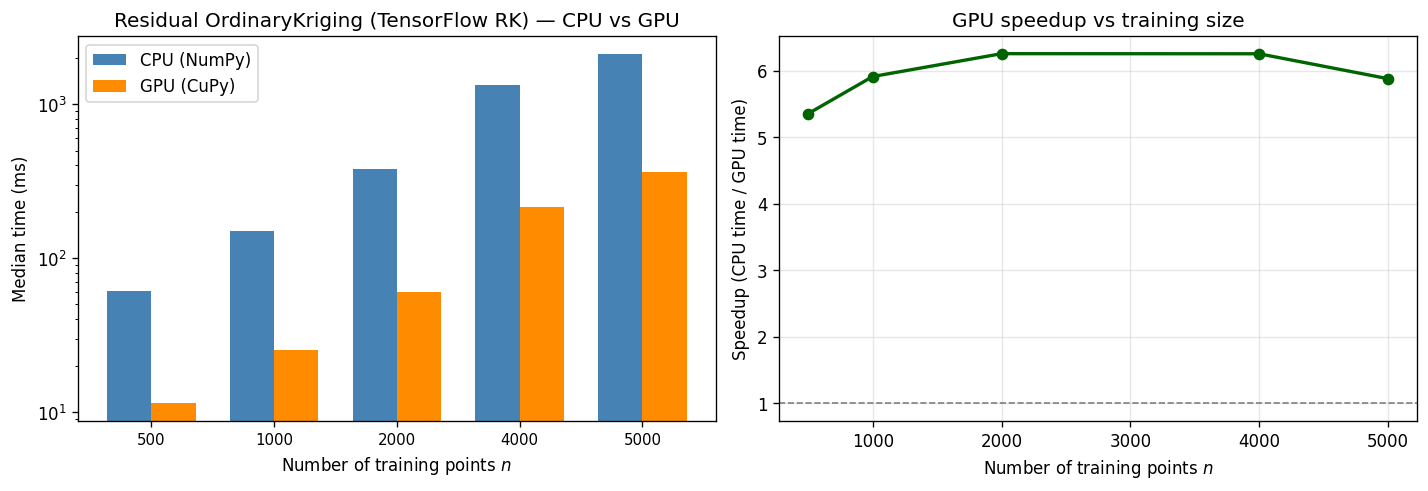

In [22]:
import time
from sklearn.linear_model import LinearRegression

from pygstat import OrdinaryKriging

N_REPEATS = 3
N_PRED_GP = 500
GP_SIZES = [500, 1000, 2000, 4000, 5000]
rng_bench = np.random.default_rng(42)

pred_idx = rng_bench.choice(len(coords_grid), size=N_PRED_GP, replace=False)
xy_pred_b = coords_grid[pred_idx]


def _residual_variogram(X_tr, y_tr, xy_tr):
    """Linear trend (CPU); residual field is what OK interpolates."""
    lin = LinearRegression().fit(np.asarray(X_tr, dtype=float), y_tr)
    resid = y_tr - lin.predict(np.asarray(X_tr, dtype=float))
    vg_kw = dict(VARIOGRAM_KWARGS)
    vg_kw.pop("use_gpu", None)
    return Variogram(
        np.asarray(xy_tr, dtype=float),
        np.asarray(resid, dtype=float),
        model="spherical",
        estimator="matheron",
        use_gpu=False,
        **vg_kw,
    ).fit(), resid


def _time_ok(xy_train, z_train, xy_pred, vg, use_gpu, repeats=N_REPEATS, warmup=True):
    """Median wall time of OrdinaryKriging.fit + predict(return_variance=True)."""
    if warmup:
        k_tr = min(40, len(xy_train))
        k_pr = min(40, len(xy_pred))
        OrdinaryKriging(vg, use_gpu=use_gpu).fit(
            xy_train[:k_tr], z_train[:k_tr]
        ).predict(xy_pred[:k_pr], return_variance=True)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        ok_m = OrdinaryKriging(vg, use_gpu=use_gpu).fit(xy_train, z_train)
        last = ok_m.predict(xy_pred, return_variance=True)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


print(f"GPU usable : {USE_GPU}")
print(f"Repeats    : {N_REPEATS}  (median wall time of residual OK fit + predict)")
print(f"GP SOC     : {len(y)} samples from data/gp_data_5000.csv")
print("Trend      : linear (MLP analogue; residual OK uses use_gpu)")
print(f"GP n_pred  : {N_PRED_GP} grid locations")
print()

rows = []
for n in GP_SIZES:
    X_tr = np.asarray(X[:n], dtype=float)
    y_tr = y[:n]
    xy_tr = coords[:n]
    vg, resid = _residual_variogram(X_tr, y_tr, xy_tr)

    cpu_t, pred_cpu = _time_ok(xy_tr, resid, xy_pred_b, vg, use_gpu=False)
    row = {
        "dataset": "GP (SOC)",
        "n_train": n,
        "n_pred": N_PRED_GP,
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_GPU:
        gpu_t, pred_gpu = _time_ok(xy_tr, resid, xy_pred_b, vg, use_gpu=True)
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        z_c, se_c = pred_cpu
        z_g, se_g = pred_gpu
        row["match"] = bool(
            np.allclose(z_c, z_g, rtol=1e-4, atol=1e-4, equal_nan=True)
            and np.allclose(se_c, se_g, rtol=1e-4, atol=1e-4, equal_nan=True)
        )
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_train"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [str(int(n)) for n in n_vals]

x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_xlabel("Number of training points $n$")
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("Residual OrdinaryKriging (TensorFlow RK) — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel("Number of training points $n$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs training size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Predictions and residual-kriging standard errors from the two backends should **match** (`match = True`). The Keras MLP trend is independent of this comparison; the GPU speedup comes from the residual OK covariance build and solve. On the Great Plains SOC prefixes the $O(n^2)$ covariance and $O(n^3)$ solve keep the GPU several times faster as $n$ grows to 5{,}000. Use `use_gpu=USE_GPU` (as the rest of this notebook does) so the same cells run on a laptop CPU or a CUDA workstation without edits.


***
## 14. Summary and Conclusions

This notebook applied **regression kriging** to Great Plains **soil organic carbon** with a **TensorFlow/Keras MLP** trend (`pygstat.DeepRegressionKrigingTF`).

- **Data.** 5,000 samples (`gp_data_5000.csv`) and a 10 km grid (`gp_grid.csv`). **NLCD** is a **categorical** land-cover class, dummy-encoded with `OneHotEncoder(drop="first")` rather than treated as an ordinal score.
- **Split.** NLCD-stratified **60% train / 20% valid / 20% test**. Train fits the trend (and Optuna CV) and residual kriging; valid is the early-stopping frame for the final MLP; test is used only for the final comparison.
- **Families.** A **default** MLP (`[128, 64, 32]`) and an **Optuna-tuned** MLP (20 trials, 3-fold CV RMSE, median pruning) were each scored on the test set. The **best of the two** was used to map SOC on the grid.
- **Mapping.** SOC, the MLP trend, kriged residuals, and kriging standard error were written to `data/gp_prediction_RK_tf.csv`.
- **CPU / GPU.** Residual ordinary kriging (`use_gpu=USE_GPU`) was timed on prefixes of `gp_data_5000.csv`. The Keras MLP uses TensorFlow's own devices; the $O(n^2)$ covariance and $O(n^3)$ OK solve are the CuPy-accelerated steps.

Regression kriging with a TensorFlow MLP is a practical workflow when you want **nonlinear capacity**, **Keras/GPU training**, **Optuna architecture search**, and **geostatistical residuals** on the same spatial support. The calling API matches tutorial 7.3 (`DeepRegressionKriging`) so the two backends can be swapped with the same code.


***
## 15. Resources

### Papers and books

| Reference | Notes |
|-----------|-------|
| Hengl, T., Heuvelink, G.B.M. & Stein, A. (2004). A generic framework for spatial prediction of soil variables based on regression-kriging. *Geoderma* 120, 75–93. | RK as used in digital soil mapping |
| Hengl, T., Heuvelink, G.B.M. & Rossiter, D.G. (2007). About regression-kriging: from equations to case studies. *Computers & Geosciences* 33, 1301–1315. | Practical RK workflow |
| Odeh, I.O.A., McBratney, A.B. & Chittleborough, D.J. (1995). Further results on prediction of soil properties from terrain attributes: heterotopic cokriging and regression-kriging. *Geoderma* 67, 215–226. | Early RK for soil properties |
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press. | SK with a varying local mean |
| Akiba, T., Sano, S., Yanase, T., Ohta, T. & Koyama, M. (2019). Optuna: A next-generation hyperparameter optimization framework. *KDD*. | TPE sampler and pruning used here |
| Abadi, M. et al. (2016). TensorFlow: A system for large-scale machine learning. *OSDI*. | Keras/TensorFlow backend used here |

### In this library

| Object | Role |
|--------|------|
| `pygstat.DeepRegressionKrigingTF` | Keras MLP trend + ordinary kriging of residuals (`use_gpu`) |
| `tune_hyperparameters=True` | Optuna search over hidden layers, dropout, learning rate, weight decay, batch size |
| `param_space` | Custom `trial -> dict` search space (defaults to `_default_param_space`) |
| `fit(..., X_val=, y_val=)` | Validation arrays for early stopping of the final MLP |
| `best_params_`, `best_score_`, `study_` | Winning hyperparameters, CV RMSE, and the Optuna study |
| `plot_losses()`, `plot_optuna_history()` | Training curves and optimization history |
| `pygstat.Variogram` | Residual (and exploratory) variogram |

Install extras with `pip install pygstat[tensorflow,optuna]`. TensorFlow uses a GPU automatically when `tf.config.list_physical_devices('GPU')` is non-empty; otherwise training runs on CPU.
